<a href="https://colab.research.google.com/github/4DChernSimonceo/CleanNOTEBOOK/blob/main/Systems_and_Controls_Epidemic_Modelling_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This assignment should hopefully take no longer than 1-2 hours to complete :)

**Instructions:**

Please complete this assignment in pairs and include the names of both you and your partner here (you can edit this cell by double clicking it):

Student 1

Student 2

!!BOTH GROUP MEMBERS MUST SUBMIT INDIVIDUALLY BUT CAN BOTH SUBMIT THE EXACT SAME CODE AS THE OTHER!!

To make a copy: File>Save a Copy in Drive
- and now you can edit your own copy!

To export this document: File>Download>Download .ipynb

You may include short answer responses either in this notebook or in an auxiliary document (please include screenshots in the latter if you choose this option)

# **1 - Introduction**

The Susceptible-Infected-Recovered (SIR) model is a fundamental compartmental model used in epidemiology to study the spread of infectious diseases. The SIR model is a simple way to understand how diseases spread in a population. It divides people into three groups:

• Susceptible (S) – These susceptible individuals (healthy people who can catch the disease.)

• Infected (I) – These are infected individuals (people who have the disease and can spread it.)

• Recovered (R) – These are people who recovered (had the disease but got better and are now immune.)

How it works: At the beginning of an epidemic of a pathogen that is new to a population, most people are
susceptible. When an infected person comes into contact with a susceptible person, they might pass on the
disease, moving that person from the S group to the I group. Over time, infected people recover and move
to the R group, meaning they can’t catch or spread the disease anymore. As more people recover, fewer
people are left to be infected, and eventually, the disease slows down and stops spreading. This model helps
scientists and doctors predict how fast diseases will spread and what we can do (like vaccination or social
distancing) to slow them down.

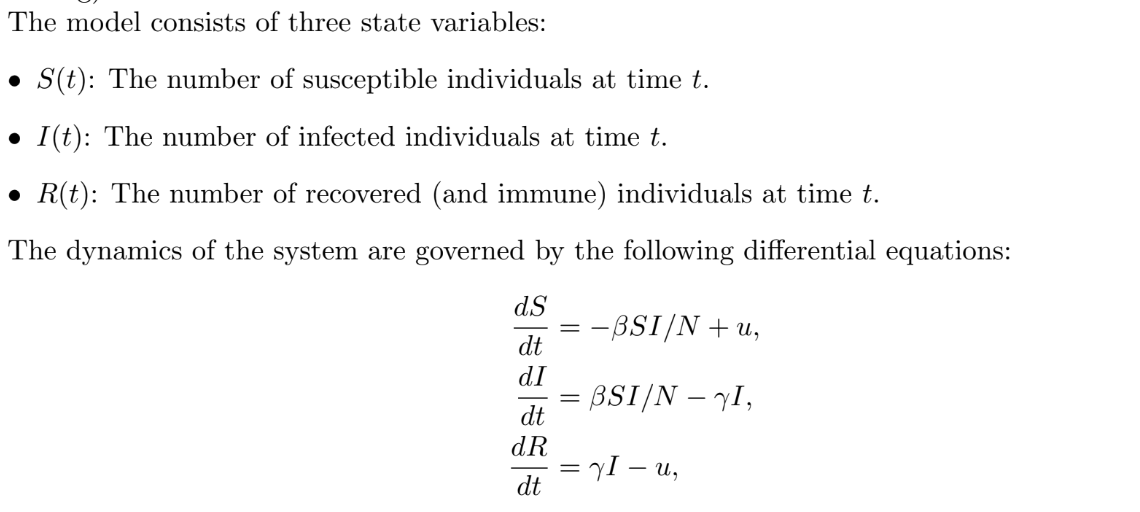

where:

• β is the transmission coefficient, or rate at which infections are generated due to contact between susceptible and infectious individuals, it represents both the rate at which contacts are made and the rate at which those contacts give rise to transmission of the pathogen.

• γ is the recovery rate,

• u(t) is the vaccination control input that moves individuals from S to R.

In this quick project, you will explore the impact of different parameters on disease spread.

## **2 Part 1: Baseline SIR Model Simulation, no control (10 marks total)**

Implement the no-control (u(t) = 0) SIR model in Python (or MATLAB) and plot the time evolution of S(t), I(t), and R(t) for the following parameters and initial conditions:

• Total population: S + I + R = N = 1000

• Initial conditions: S(0) = 999, I(0) = 1, R(0) = 0

• Infection rate: β = 0.3, Recovery rate: γ = 0.1

• Simulation time: t = 0 to 100 days

Vary β (0.3, 0.6) and γ (0.1, 0.5) and observe how they impact the trajectories. Have plots for each pair of parameters (4 total.) For each parameter, discuss what you observe in the trajectories.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define model parameters
beta = 0.3   # Infection rate
gamma = 0.1  # Recovery rate
N = 1000     # Total population

# Initial conditions
S0 = 999
I0 = 1
R0 = 0

# Time span for simulation
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# SIR model without vaccination
def sir_model(t, y, beta, gamma):
    S, I, R = y
    dSdt =####FILL IN
    dIdt =####FILL IN
    dRdt =####FILL IN
    return [dSdt, dIdt, dRdt]

# Solve the system
sol = solve_ivp(sir_model, t_span, [S0, I0, R0], args=(beta, gamma), t_eval=t_eval)
t = sol.t
S, I, R = sol.y

# Plot 4 cases of results
####FILL IN


# **3 Part 2: Introducing a Vaccination Control Input (10 marks total)**

1. Modify the model by introducing a vaccination control input u(t), which moves individuals directly
from S to R.

2. Assume a proportional vaccine control strategy as follows:

      u(t) = kS(t)
      
      where k is a vaccination rate.

3. Implement and simulate the controlled system for different values of k ranging from 0.00 to 0.1 at 0.02 step intervals. Observe how S, I, and R change.

Note: This will result in 6 SIR plots.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define model parameters
beta = 0.3   # Infection rate
gamma = 0.1  # Recovery rate
N = 1000     # Total population

# Initial conditions
S0 = 999
I0 = 1
R0 = 0

# Time span for simulation
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Define the vaccination function
def u(t, S, k):
    ####FILL IN
    return ####FILL IN

# SIR model with vaccination
def sir_vaccine_corrected(t, y, beta, gamma, k):
    S, I, R = y
    vaccination = u(t, S, k)  # Apply vaccination control
    # Ensure total vaccination does not exceed U_max


    dSdt =####FILL IN
    dIdt =####FILL IN
    dRdt =####FILL IN
    return [dSdt, dIdt, dRdt]

# Define different vaccination rates to test
k_values = np.linspace(0, 0.1, 6)

# Simulate and plot for different k values
for i, k in enumerate(k_values):
    sol = solve_ivp(sir_vaccine_corrected, t_span, [S0, I0, R0], args=(beta, gamma, k), t_eval=t_eval)
    t = sol.t
    S, I, R = sol.y

# Create subplots for different k values


# **4 Part 3: Exploring epidemic control strategies (15 marks total)**

Note:
Run the following code and describe the SIR trajectories that you observe. Note, the main objective of this part isn't to write code but rather understand what each of these blocks are trying to achieve and then coming up with an interpretation



# No Intervention (4 marks)

All you need to do is run the code below. Explain what each of the model parameters are and what certain lines of code are doing (tagged with #EXPLAIN). You can either explain as a comment in the code or below the cell. There are 3[link text](https://) lines you need to explain in the below cell

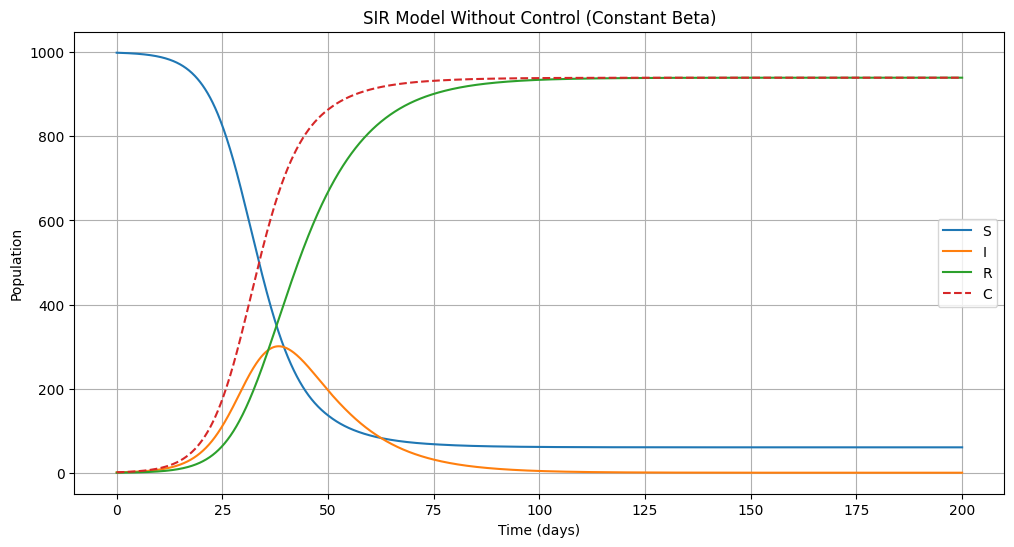

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define model parameters
beta0 = 0.3   # Constant infection rate (no control)
gamma = 0.1   # Recovery rate
N = 1000      # Total population
T = 200       ###################################### EXPLAIN 1

# Initial conditions
S0 = 999  # Susceptible individuals
I0 = 1    # Infected individuals
R0 = 0    # Recovered individuals
C0 = 1    ###################################### EXPLAIN 2

t_eval = np.linspace(0, T, 2000)  ###################################### EXPLAIN 3

# SIR model without control (constant beta)
def sir_no_control_model(t, y, beta, gamma, N):
    S, I, R, C = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    dCdt = beta * S * I / N

    return [dSdt, dIdt, dRdt, dCdt]

# Solve the system with constant beta
sol_no_control = solve_ivp(sir_no_control_model, (0, T), [S0, I0, R0, C0],
                           args=(beta0, gamma, N), t_eval=t_eval)

# Extract results
t = sol_no_control.t
S, I, R, C = sol_no_control.y

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(t, S, label="S")
plt.plot(t, I, label="I")
plt.plot(t, R, label="R")
plt.plot(t, C, label="C", linestyle='dashed')

plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.title("SIR Model Without Control (Constant Beta)")
plt.legend()
plt.grid()
plt.show()


## Vaccination Control (4 marks)

All you need to do is run the code below. Explain what each of the model parameters are and what certain lines of code are doing (tagged with #EXPLAIN). You can either explain as a comment in the code or below the cell. There are 4 lines you need to explain in the below cell

Minimum S(t): 96.9217
Minimum I(t): 0.0095
Final W(T) from solver: 200.0376 (limit = 200.0)


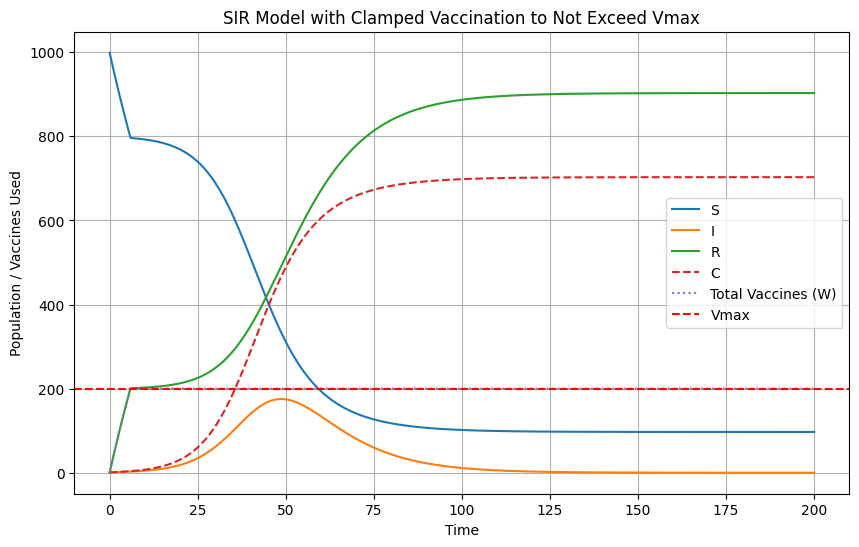

Final C(T): 703.04 infections
Total Vaccines W(T): 200.04 (limit = 200.0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# =============================================================================
# 1. Model Parameters
# =============================================================================
beta = 0.3        # Infection rate
gamma = 0.1       # Recovery rate
N = 1000 # Population

T = 200 ###################################### EXPLAIN 1 (same as above cell)
Vmax = 200.0   ###################################### EXPLAIN 2

# Initial states: [S, I, R, C, W]
S0, I0, R0, C0, W0 = 999.0, 1.0, 0.0, 1.0, 0.0

t_eval = np.linspace(0, T, 1000)

# Suppose we want to find an optimal k(t) in [k_lower, k_upper],
# discretized over 5 intervals:
num_intervals = 5
t_control = np.linspace(0, T, num_intervals)
k_lower, k_upper = 0.01, 0.05

# =============================================================================
# 2. Clamped SIR Model: If W >= Vmax, set vaccination = 0
# =============================================================================
def sir_vaccination_clamped(t, y, k_func, beta, gamma, N, Vmax):

    S, I, R, C, W = y

    # 1) Compute leftover supply
    leftover = Vmax - W

    # 2) Compute desired vaccination rate
    k_val = k_func(t)
    desired_u = k_val * S ###################################### EXPLAIN 3

    if leftover <= 0: ###################################### EXPLAIN 4
        u = 0.0
    else:
        u = desired_u

    # Standard SIR with vaccination
    dSdt = -beta*(S*I/N) - u
    dIdt =  beta*(S*I/N) - gamma*I
    dRdt =  gamma*I + u
    dCdt =  beta*(S*I/N)
    dWdt =  u

    return [dSdt, dIdt, dRdt, dCdt, dWdt]

# =============================================================================
# 3. Piecewise-Constant k(t)
# =============================================================================
def k_piecewise(t, k_vals):
    """
    Given k_vals (one per interval), interpolate over t_control.
    """
    return np.interp(t, t_control, k_vals)

# =============================================================================
# 4. Objective: Minimize C(T)
# =============================================================================
def objective(k_vals):
    # Build a local function for the vaccination rate
    def k_func(t):
        return k_piecewise(t, k_vals)

    sol = solve_ivp(
        sir_vaccination_clamped,
        (0, T),
        [S0, I0, R0, C0, W0],
        args=(k_func, beta, gamma, N, Vmax),
        t_eval=t_eval
    )
    # We want the final cumulative infections
    return sol.y[3, -1]  # C(T)

# =============================================================================
# 5. Optimization
# =============================================================================
# Initial guess
k_init = np.full(num_intervals, 0.5*(k_lower + k_upper))
bounds = [(k_lower, k_upper)] * num_intervals

# We do NOT need an inequality constraint on total vaccines; the ODE clamps usage
res = minimize(
    objective,
    k_init,
    method='SLSQP',
    bounds=bounds,
    options={'maxiter': 100}
)
if not res.success:
    print("Optimization failed:", res.message)

k_opt = res.x

# =============================================================================
# 6. Solve again with the optimal control
# =============================================================================
def k_opt_func(t):
    return k_piecewise(t, k_opt)

sol_opt = solve_ivp(
    sir_vaccination_clamped,
    (0, T),
    [S0, I0, R0, C0, W0],
    args=(k_opt_func, beta, gamma, N, Vmax),
    t_eval=t_eval,
    max_step=0.1,      # Forces smaller steps (adjust as needed)
    rtol=1e-6, atol=1e-8  # Tighter tolerances to improve accuracy
)


t_sol = sol_opt.t
S_opt, I_opt, R_opt, C_opt, W_opt = sol_opt.y

print(f"Minimum S(t): {np.min(S_opt):.4f}")
print(f"Minimum I(t): {np.min(I_opt):.4f}")
print(f"Final W(T) from solver: {W_opt[-1]:.4f} (limit = {Vmax})")

# =============================================================================
# 7. Plot
# =============================================================================
plt.figure(figsize=(10,6))
plt.plot(t_sol, S_opt, label='S')
plt.plot(t_sol, I_opt, label='I')
plt.plot(t_sol, R_opt, label='R')
plt.plot(t_sol, C_opt, label='C', linestyle='--')
plt.plot(t_sol, W_opt, label='Total Vaccines (W)', linestyle=':')
plt.axhline(Vmax, color='r', linestyle='--', label='Vmax')
plt.xlabel("Time")
plt.ylabel("Population / Vaccines Used")
plt.title("SIR Model with Clamped Vaccination to Not Exceed Vmax")
plt.legend()
plt.grid()
plt.show()

# Inspect final
print(f"Final C(T): {C_opt[-1]:.2f} infections")
print(f"Total Vaccines W(T): {W_opt[-1]:.2f} (limit = {Vmax})")


## Social Distancing Control (7 marks)

All you need to do is run the code below. Nothing to explain

**!!!!!NOTE!!!!! Short answer question below this cell**

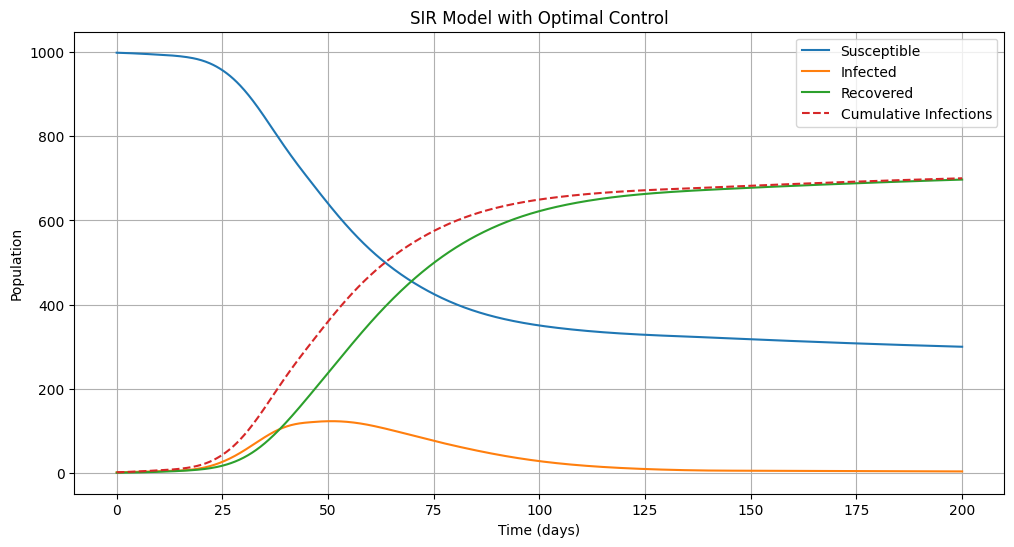

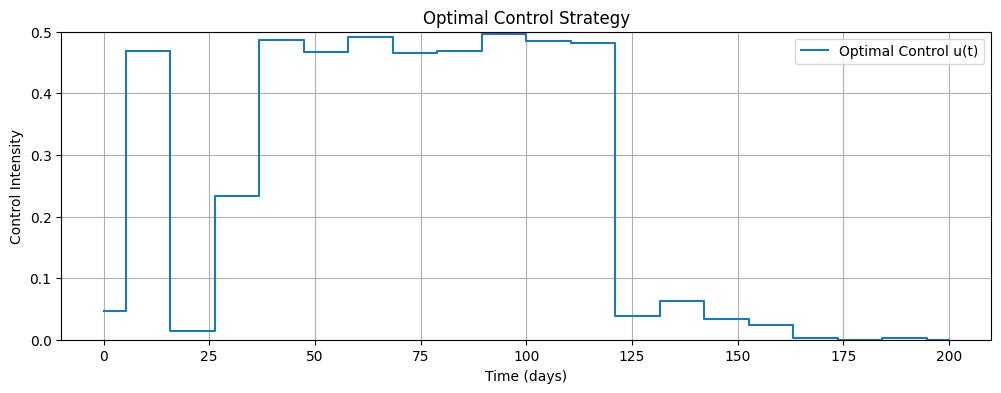

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# =============================================================================
# 1. Define Model Parameters
# =============================================================================
beta0 = 0.3     # Uncontrolled infection rate
gamma = 0.1     # Recovery rate
N = 1000        # Total population
umax = 0.5      # Maximum control level
Tmax = 50       # Total allowed intervention days
T = 200

# Initial conditions
S0 = 999        # Susceptible individuals
I0 = 1          # Infected individuals
R0 = 0          # Recovered individuals
C0 = 1

# Time span and evaluation points
t_eval = np.linspace(0, T, 1000)    # Evaluation points for the solver

# Define the number of control intervals
num_control_intervals = 20
t_control = np.linspace(0, T, num_control_intervals)

# =============================================================================
# 2. Define the SIR Model with Control
# =============================================================================
def sir_control_model(t, y, beta_func, gamma, N):

    S, I, R, C = y

    # Effective infection rate is scaled by (1 - control)
    beta_t = beta0 * (1 - beta_func(t))

    dSdt = -beta_t * (S * I / N)
    dIdt =  beta_t * (S * I / N) - gamma * I
    dRdt =  gamma * I
    dCdt =  beta_t * (S * I / N)  # Tracks cumulative infections

    return [dSdt, dIdt, dRdt, dCdt]

# =============================================================================
# 3. Define the Control Function
# =============================================================================
def control_function(t, u_vals):

    return np.interp(t, t_control, u_vals)

# =============================================================================
# 4. Define the Objective Function
#    We want to minimize the final size of cumulative infections.
# =============================================================================
def objective(u_vals):
    """
    Objective function that computes total cumulative infections at the end
    of the simulation for a given control strategy.

    Parameters:
    -----------
    u_vals : ndarray
        Control values to be applied at each interval.

    Returns:
    --------
    float
        Final cumulative infections (to be minimized).
    """
    # Create a lambda to pass into the SIR model
    beta_func = lambda t: control_function(t, u_vals)

    # Solve the SIR model over time
    sol = solve_ivp(
        sir_control_model,
        (0, T),
        [S0, I0, R0, C0],
        args=(beta_func, gamma, N),
        t_eval=t_eval
    )

    # The fourth state variable (C) represents cumulative infections
    return sol.y[3, -1]

# =============================================================================
# 5. Define the Hard Constraint
#    We limit the total "area under the curve" of the control to Tmax.
# =============================================================================
def constraint(u_vals):
    """
    Constraint ensuring that the total integrated intervention over time
    does not exceed a maximum allowable value (Tmax).

    Parameters:
    -----------
    u_vals : ndarray
        Control values at each control point.

    Returns:
    --------
    float
        Constraint value (must be >= 0 to be feasible).
    """
    # Numerical integration (using trapezoidal rule) of the control over time
    total_control = np.trapz(u_vals, t_control)
    return Tmax - total_control

# =============================================================================
# 6. Set Up and Solve the Optimization Problem
# =============================================================================
# Initial guess for the control values
u0 = np.zeros(num_control_intervals)

# Bounds for each control value (between 0 and umax)
bounds = [(0, umax)] * num_control_intervals

# Define the constraint in a format acceptable by 'minimize'
cons = [{'type': 'ineq', 'fun': constraint}]

# Perform the minimization using SLSQP
res = minimize(
    objective,
    u0,
    bounds=bounds,
    constraints=cons,
    method='SLSQP',
    options={'maxiter': 100}
)

# Check if optimization was successful
if res.success:
    nu_opt = res.x
else:
    print("Optimization failed:", res.message)
    # Use the initial guess as a fallback if it fails
    nu_opt = u0

# =============================================================================
# 7. Simulate the System Using the Optimal Control
# =============================================================================
beta_opt_func = lambda t: control_function(t, nu_opt)

sol_opt = solve_ivp(
    sir_control_model,
    (0, T),
    [S0, I0, R0, C0],
    args=(beta_opt_func, gamma, N),
    t_eval=t_eval
)

# Extract solution
t_sol = sol_opt.t
S_opt, I_opt, R_opt, C_opt = sol_opt.y

# =============================================================================
# 8. Plot the Results
# =============================================================================

# (a) S, I, R, C vs Time
plt.figure(figsize=(12, 6))
plt.plot(t_sol, S_opt, label="S")
plt.plot(t_sol, I_opt, label="I")
plt.plot(t_sol, R_opt, label="R")
plt.plot(t_sol, C_opt, label="C", linestyle='dashed')

plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.title("SIR Model with Optimal Control")
plt.legend()
plt.grid()
plt.show()

# (b) Optimal Control Strategy
plt.figure(figsize=(12, 4))
plt.step(
    t_control,
    nu_opt,
    where='mid',
    label="Optimal Control u(t)"
)
plt.xlabel("Time (days)")
plt.ylabel("Control Intensity")
plt.title("Optimal Control Strategy")
plt.ylim(0, umax)
plt.legend()
plt.grid()
plt.show()


Question 1: Distinguish between the two different strategies in terms of the time periods in which control occurs. Given your pandemic experience, what is an additional constraint you would add to the vaccination control optimization and to the social distancing control optimization to make it more realistic?


Question 2: What is a practical interpretation of the umax for social distancing (maximum control level?) What are some policies that could be implemented to achieve the optimal control graph. Would this work or not work. Similarly to question 1, what are some additional changes you would need to make to the control problem to make these changes more socially acceptable/reasonable?

# 5 Part 4 Optimal Vaccine Rollout with Finite Stock and Waning Immunity (20 marks)

In this part, you will study a **resource allocation control problem** using an epidemic model.

We assume a finite vaccine budget and ask how to deploy it over time to reduce total infections.

### Model extension: waning immunity

In the basic SIR model, recovered individuals remain immune forever. Here, we introduce **waning immunity**, meaning recovered or vaccinated individuals can lose immunity and return to the susceptible pool.

The model is:

$$
\dot S = -\beta \frac{SI}{N} - u(t) + \omega R
$$

$$
\dot I = \beta \frac{SI}{N} - \gamma I
$$

$$
\dot R = \gamma I + u(t) - \omega R
$$

We also track cumulative infections:

$$
\dot C = \beta \frac{SI}{N}
$$

where:

* $S(t)$ = susceptible population
* $I(t)$ = infected population
* $R(t)$ = recovered/immune population
* $C(t)$ = cumulative infections
* $u(t)$ = vaccination rollout rate (control input)
* $\omega$ = waning immunity rate

### Why this creates a control tradeoff

If immunity wanes, vaccinating everyone as early as possible may be **suboptimal** because some immunity may be lost before the highest-risk period of the outbreak.

This means the timing of vaccination matters, not just the total amount.

### Control objective

We want to choose a vaccination rollout $u(t)$ over a fixed horizon $[0, T]$ to minimize final cumulative infections:

$$
\min ; C(T)
$$

subject to:

* rollout rate constraint: $0 \le u(t) \le u_{\max}$
* total vaccine budget constraint: $\int_0^T u(t),dt \le V_{\max}$

### What the code does

The code below:

1. Simulates the SIR model with waning immunity and vaccination.
2. Parameterizes the vaccination rollout using a small number of control points ("knots").
3. Optimizes the rollout to minimize cumulative infections.
4. Compares the optimized rollout to two baseline policies:

   * **All upfront** (use vaccines as fast as possible at the beginning)
   * **Uniform rollout** (spread vaccines evenly over time)

### Your job

You will **run experiments by changing model and control parameters** and answer short questions about:

* when front-loading is best,
* when spreading/delaying vaccination helps,
* how actuator limits ($u_{\max}$) affect the rollout,
* and how epidemic dynamics interact with control design.


NOTE: Short answer questions below! Run the code and answer them

/tmp/ipykernel_2258/606905935.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_vaccines_used = np.trapz(np.clip(u_vals, 0.0, umax), t_control)
/tmp/ipykernel_2258/606905935.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  budget_used_opt_dense = np.trapz(np.clip(u_opt_dense, 0.0, umax), t_eval)
/tmp/ipykernel_2258/606905935.py:175: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Optimized (trapz on knots) : {np.trapz(np.clip(u_opt, 0.0, umax), t_control):.2f} / {Vmax:.2f}")


Optimization success: True
Final cumulative infections C(T):
  Optimized rollout : 1434.49
  All upfront       : 1522.45
  Uniform rollout   : 1513.67

Budget check:
  Optimized (trapz on knots) : 200.00 / 200.00
  Optimized (dense grid)     : 200.00 / 200.00
  Upfront policy (analytic)  : 200.00 / 200.00
  Uniform policy (analytic)  : 200.00 / 200.00


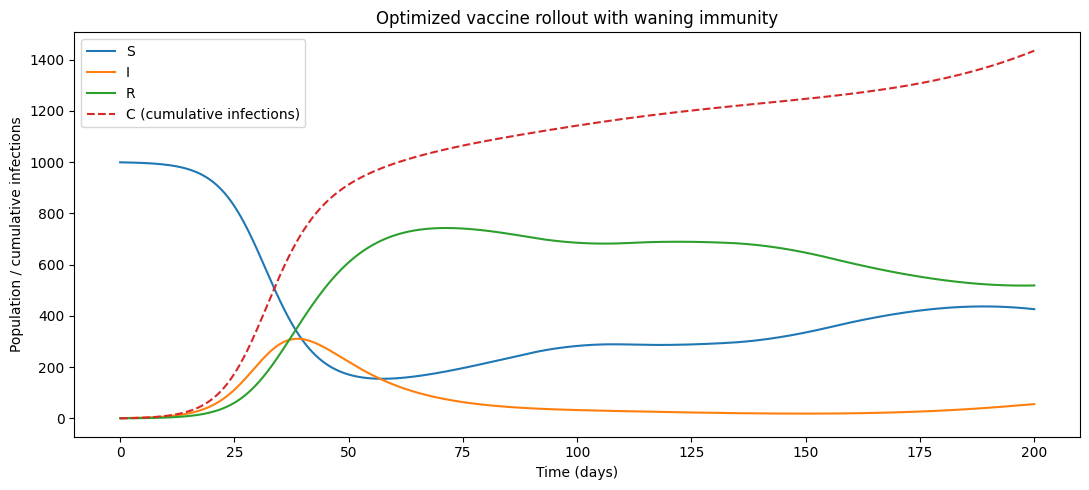

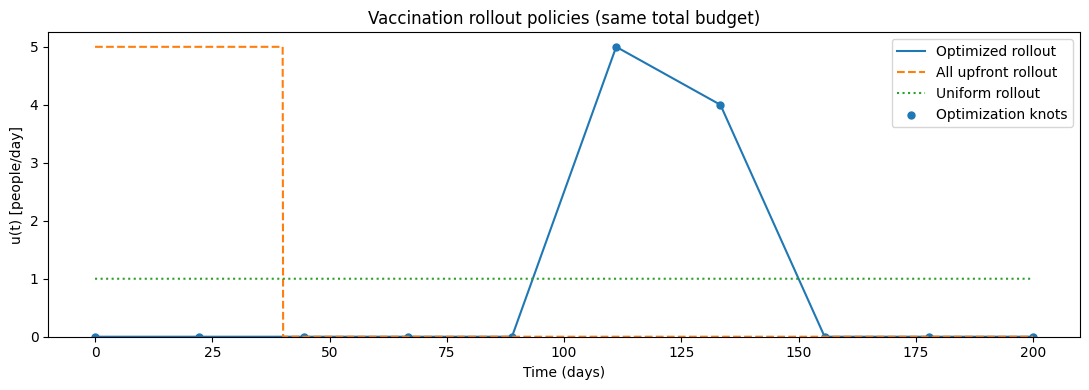

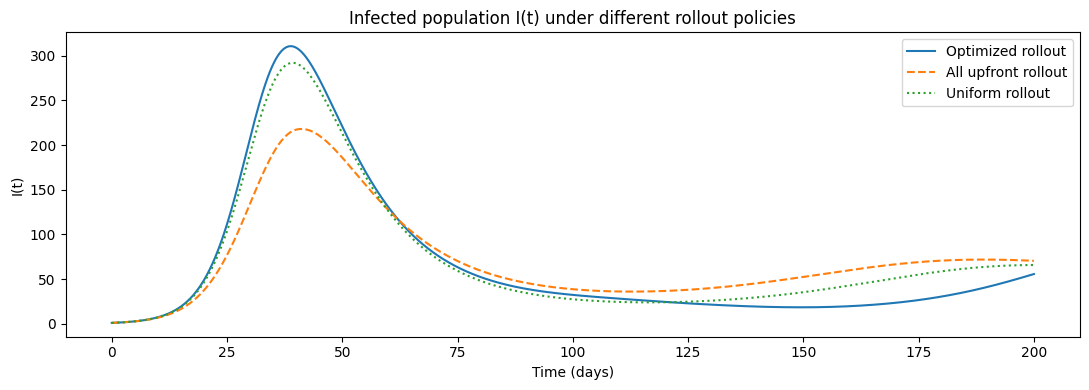

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# ==============================
# PART 3: Optimal vaccine rollout with waning immunity
# ==============================

# ------------------------------
# Model parameters (students can adjust these)
# ------------------------------
N = 1000
S0, I0, R0, C0 = 999, 1, 0, 0

beta = 0.3
gamma = 0.1
omega = 0.01   # waning immunity rate (important for timing tradeoff)

T = 200
t_eval = np.linspace(0, T, 2001)

Vmax = 200.0   # total vaccine budget (people)
umax = 5.0     # max rollout rate (people/day)

num_control_knots = 10
t_control = np.linspace(0, T, num_control_knots)

# ------------------------------
# Rollout parameterization
# ------------------------------
def control_piecewise(t, u_vals):
    """
    Vaccination rollout u(t) parameterized by values at control knots.
    We use linear interpolation for smoothness and simplicity.
    """
    return np.interp(t, t_control, u_vals)

# ------------------------------
# SIR model with waning immunity + vaccination
# State: [S, I, R, C]
#   S = susceptible
#   I = infected
#   R = recovered/immune
#   C = cumulative infections
# ------------------------------
def sir_waning_vaccine(t, y, u_func, beta, gamma, omega, N):
    S, I, R, C = y

    # Vaccination rate (clipped to feasible bounds)
    u = float(u_func(t))
    u = np.clip(u, 0.0, umax)
    u = min(u, max(S, 0.0))  # cannot vaccinate more people/day than susceptible pool

    infection_flow = beta * S * I / N

    dSdt = -infection_flow - u + omega * R
    dIdt =  infection_flow - gamma * I
    dRdt =  gamma * I + u - omega * R
    dCdt =  infection_flow
    return [dSdt, dIdt, dRdt, dCdt]

# ------------------------------
# Simulation helpers
# ------------------------------
def simulate_with_control(u_vals):
    """
    Simulate using knot-parameterized rollout values u_vals.
    """
    def u_func(t):
        return control_piecewise(t, u_vals)

    sol = solve_ivp(
        sir_waning_vaccine,
        (0, T),
        [S0, I0, R0, C0],
        args=(u_func, beta, gamma, omega, N),
        t_eval=t_eval,
        max_step=0.5
    )
    return sol

def simulate_callable_control(u_callable):
    """
    Simulate using a directly specified rollout function u(t).
    """
    sol = solve_ivp(
        sir_waning_vaccine,
        (0, T),
        [S0, I0, R0, C0],
        args=(u_callable, beta, gamma, omega, N),
        t_eval=t_eval,
        max_step=0.5
    )
    return sol

# ------------------------------
# Optimization objective + constraint
# ------------------------------
def objective(u_vals):
    """
    Minimize final cumulative infections C(T).
    """
    sol = simulate_with_control(u_vals)
    return sol.y[3, -1]

def vaccine_budget_constraint(u_vals):
    """
    Enforce total vaccine usage <= Vmax.
    Since u(t) is parameterized at knots, we approximate the total budget
    using trapezoidal integration over the knot values.
    Constraint format for SLSQP: must be >= 0.
    """
    total_vaccines_used = np.trapz(np.clip(u_vals, 0.0, umax), t_control)
    return Vmax - total_vaccines_used

# ------------------------------
# Solve optimal control (over knot values)
# ------------------------------
u0 = np.zeros(num_control_knots)
bounds = [(0.0, umax)] * num_control_knots
constraints = [{'type': 'ineq', 'fun': vaccine_budget_constraint}]

res = minimize(
    objective,
    u0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 300, 'ftol': 1e-6}
)

if not res.success:
    print("Optimization did not fully converge:", res.message)

u_opt = res.x if res.success else u0

# ------------------------------
# Baseline policies for comparison
# ------------------------------
# 1) All-upfront rollout: vaccinate at umax until budget is exhausted, then stop
duration_upfront = Vmax / umax

def upfront_control(t):
    return umax if t <= duration_upfront else 0.0

# 2) Uniform rollout: spread budget evenly over [0, T]
uniform_rate = min(Vmax / T, umax)  # clip for safety if Vmax/T > umax

def uniform_control(t):
    return uniform_rate

# ------------------------------
# Simulate all three policies
# ------------------------------
sol_opt = simulate_with_control(u_opt)
sol_upfront = simulate_callable_control(upfront_control)
sol_uniform = simulate_callable_control(uniform_control)

C_opt_final = sol_opt.y[3, -1]
C_upfront_final = sol_upfront.y[3, -1]
C_uniform_final = sol_uniform.y[3, -1]

# Estimate vaccine used by optimized policy on dense grid (more accurate than knot-only estimate)
u_opt_dense = np.interp(t_eval, t_control, u_opt)
budget_used_opt_dense = np.trapz(np.clip(u_opt_dense, 0.0, umax), t_eval)

print(f"Optimization success: {res.success}")
print("Final cumulative infections C(T):")
print(f"  Optimized rollout : {C_opt_final:.2f}")
print(f"  All upfront       : {C_upfront_final:.2f}")
print(f"  Uniform rollout   : {C_uniform_final:.2f}")
print()
print(f"Budget check:")
print(f"  Optimized (trapz on knots) : {np.trapz(np.clip(u_opt, 0.0, umax), t_control):.2f} / {Vmax:.2f}")
print(f"  Optimized (dense grid)     : {budget_used_opt_dense:.2f} / {Vmax:.2f}")
print(f"  Upfront policy (analytic)  : {Vmax:.2f} / {Vmax:.2f}")
print(f"  Uniform policy (analytic)  : {uniform_rate*T:.2f} / {Vmax:.2f}")

# ------------------------------
# Plot 1: State trajectories for optimized policy
# ------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sol_opt.t, sol_opt.y[0], label="S")
ax.plot(sol_opt.t, sol_opt.y[1], label="I")
ax.plot(sol_opt.t, sol_opt.y[2], label="R")
ax.plot(sol_opt.t, sol_opt.y[3], label="C (cumulative infections)", linestyle="--")
ax.set_title("Optimized vaccine rollout with waning immunity")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Population / cumulative infections")
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# Plot 2: Rollout policy comparison
# ------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_eval, u_opt_dense, label="Optimized rollout")
ax.plot(t_eval, [upfront_control(t) for t in t_eval], label="All upfront rollout", linestyle="--")
ax.plot(t_eval, [uniform_control(t) for t in t_eval], label="Uniform rollout", linestyle=":")
ax.scatter(t_control, u_opt, s=25, label="Optimization knots")
ax.set_title("Vaccination rollout policies (same total budget)")
ax.set_xlabel("Time (days)")
ax.set_ylabel("u(t) [people/day]")
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# Plot 3: Compare infected trajectories across policies (optional but very useful)
# ------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sol_opt.t, sol_opt.y[1], label="Optimized rollout")
ax.plot(sol_upfront.t, sol_upfront.y[1], label="All upfront rollout", linestyle="--")
ax.plot(sol_uniform.t, sol_uniform.y[1], label="Uniform rollout", linestyle=":")
ax.set_title("Infected population I(t) under different rollout policies")
ax.set_xlabel("Time (days)")
ax.set_ylabel("I(t)")
ax.legend()
plt.tight_layout()
plt.show()

Question 1. Baseline policy comparison

Run the code with the default parameters and report the final cumulative infections $C(T)$ for:

*  optimized rollout,

*  all-upfront rollout,

*  uniform rollout.

Which policy performs best, and why can the rollout shape alone be misleading?

Question 2. Waning immunity and timing tradeoff

Vary omega over at least 4 values (for example: 0.0, 0.005, 0.01, 0.02, 0.03) while keeping other parameters fixed.

How does increasing omega change the optimized rollout timing, and when does spreading/delaying vaccination become more effective than front-loading?

Question 3. Epidemic dynamics and control timing

Vary beta over at least 3 values (for example: 0.2, 0.3, 0.5) while keeping gamma fixed.

How does changing beta affect both the infected trajectory $I(t)$ and the timing of the optimized rollout?

Question 4. Constraint effects (choose one sweep)

Choose one parameter to vary:

*  umax (e.g., 2, 5, 10) or

*  Vmax (e.g., 50, 100, 200, 300)

Describe how your chosen constraint changes (i) the optimized rollout shape and (ii) the performance gap between the optimized and baseline policies.

## **6 Part 5 Modelling Quarantining (5 marks)**

Question: How would you account for quarantining of i) susceptible individuals and ii) infected individuals in the model? No need to write any equations but would this impact model parameters or states to describe these individuals.